# Fairness Aware Custom Neural Network Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import KNNImputer
from imblearn.over_sampling import SMOTE

In [2]:
df_stk = pd.read_csv("healthcare-dataset-stroke-data.csv")
df_stk

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


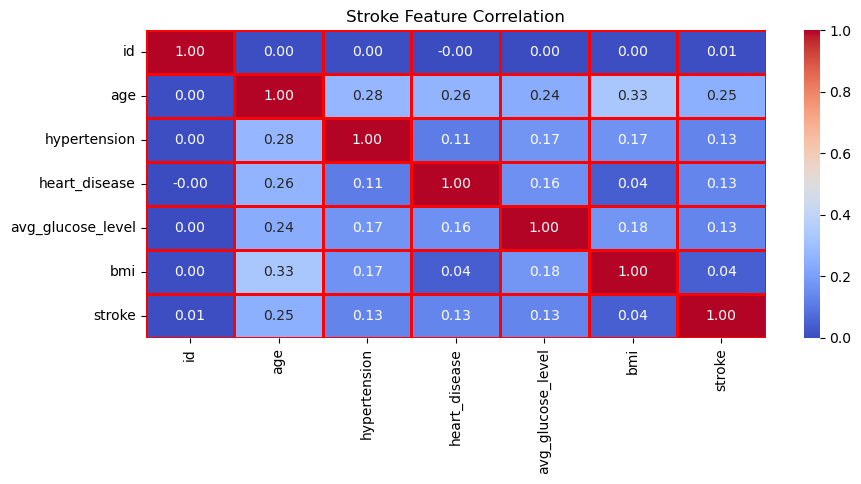

In [3]:
plt.figure(figsize=(10, 4))
sns.heatmap(df_stk.corr(numeric_only=True),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=1,
            linecolor='red')
plt.title('Stroke Feature Correlation')
#plt.savefig('stroke_correlation.png')
plt.show()

In [4]:
df_stk.drop(columns=["id"], inplace=True)                 
df_stk = df_stk[df_stk["gender"] != "Other"] 
df_stk

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [5]:
df_stk.reset_index(drop=True, inplace=True)

In [6]:
binary_cols = ["gender", "ever_married", "Residence_type"]
le = LabelEncoder()
for col in binary_cols:
    df_stk[col] = le.fit_transform(df_stk[col])   

df_stk = pd.get_dummies(df_stk, columns=["work_type", "smoking_status"], drop_first=True) 

In [7]:
df_stk["age_group"] = pd.cut(df_stk["age"], bins=[0, 40, 60, 120], labels=["<40", "40-60", ">60"])

In [8]:
X_stk = df_stk.drop(columns=["stroke", "age_group"]) 
y_stk = df_stk["stroke"]   
# save for fairness analysis
protected_stk = df_stk[["gender", "age_group"]] 

In [9]:
X_train_stk, X_test_stk, y_train_stk, y_test_stk, prot_train_stk, prot_test_stk = train_test_split(X_stk, y_stk, protected_stk, test_size=0.2, random_state=42, stratify=y_stk)

In [10]:
df_stk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5109 entries, 0 to 5108
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   gender                          5109 non-null   int64   
 1   age                             5109 non-null   float64 
 2   hypertension                    5109 non-null   int64   
 3   heart_disease                   5109 non-null   int64   
 4   ever_married                    5109 non-null   int64   
 5   Residence_type                  5109 non-null   int64   
 6   avg_glucose_level               5109 non-null   float64 
 7   bmi                             4908 non-null   float64 
 8   stroke                          5109 non-null   int64   
 9   work_type_Never_worked          5109 non-null   bool    
 10  work_type_Private               5109 non-null   bool    
 11  work_type_Self-employed         5109 non-null   bool    
 12  work_type_children  

In [11]:
print(df_stk['bmi'].isnull().sum())

201


In [12]:
imputer_stk = KNNImputer(n_neighbors=5)
X_train_stk["bmi"] = imputer_stk.fit_transform(X_train_stk[["bmi"]])   
X_test_stk["bmi"]  = imputer_stk.transform(X_test_stk[["bmi"]])

In [13]:
scaler_stk = StandardScaler()
X_train_stk_scaled = scaler_stk.fit_transform(X_train_stk)        
X_test_stk_scaled  = scaler_stk.transform(X_test_stk) 
print("scaled tranind shape:", X_train_stk_scaled.shape)

scaled tranind shape: (4087, 15)


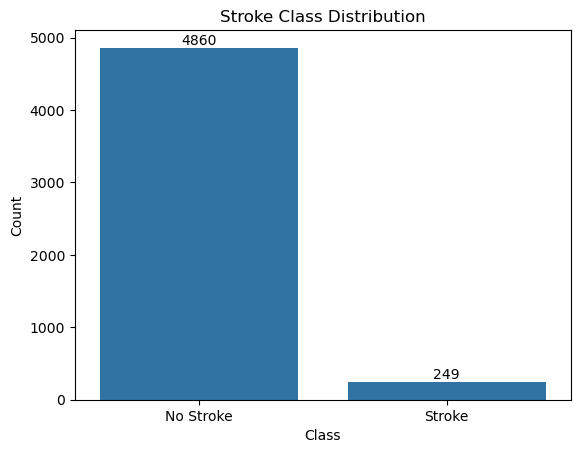

stroke
0    4860
1     249
Name: count, dtype: int64

In [14]:
ax = sns.countplot(x="stroke", data=df_stk)
plt.title("Stroke Class Distribution")
plt.xticks([0, 1], ["No Stroke", "Stroke"])
plt.xlabel("Class")
plt.ylabel("Count")

for container in ax.containers:
    ax.bar_label(container)
plt.savefig('stroke_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
df_stk['stroke'].value_counts()

In [15]:
smote = SMOTE(random_state=42)
X_train_stk_bal, y_train_stk_bal = smote.fit_resample(X_train_stk_scaled, y_train_stk)
print("New Balanced Training shape:", X_train_stk_bal.shape)
print(f"Train class distribution after SMOTE: {pd.Series(y_train_stk_bal).value_counts().to_dict()}")
print(f"Test class distribution (original): {y_test_stk.value_counts().to_dict()}")

New Balanced Training shape: (7776, 15)
Train class distribution after SMOTE: {0: 3888, 1: 3888}
Test class distribution (original): {0: 972, 1: 50}


In [16]:
df_ht = pd.read_csv("heart.csv")
df_ht

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


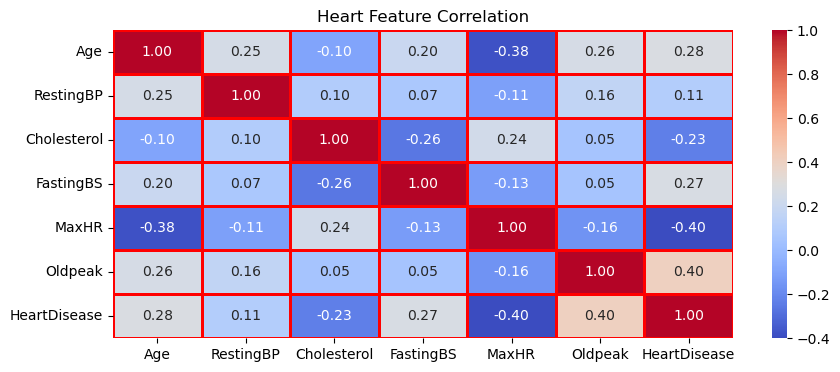

In [17]:
plt.figure(figsize=(10, 4))
sns.heatmap(df_ht.corr(numeric_only=True),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=1,
            linecolor='red')
plt.title('Heart Feature Correlation')
plt.savefig('heart_correlation.png')
plt.show()

In [18]:
df_ht.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


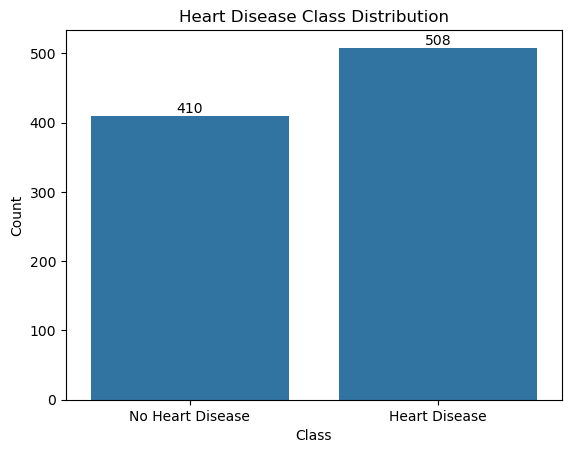

HeartDisease
1    508
0    410
Name: count, dtype: int64

In [19]:
ax = sns.countplot(x="HeartDisease", data=df_ht)
plt.title("Heart Disease Class Distribution")
plt.xticks([0, 1], ["No Heart Disease", "Heart Disease"])
plt.xlabel("Class")
plt.ylabel("Count")

for container in ax.containers:
    ax.bar_label(container)

plt.savefig('heart_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
df_ht['HeartDisease'].value_counts()

In [20]:
df_ht.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

In [21]:
binary_cols_ht = ["Sex", "ExerciseAngina"]
for col in binary_cols_ht:
    df_ht[col] = le.fit_transform(df_ht[col])

df_ht = pd.get_dummies(df_ht, columns=["ChestPainType", "RestingECG", "ST_Slope"], drop_first=True)

In [22]:
df_ht["age_group"] = pd.cut(df_ht["Age"], bins=[0, 40, 60, 120], labels=["<40", "40-60", ">60"])

In [23]:
X_ht = df_ht.drop(columns=["HeartDisease", "age_group"])
y_ht = df_ht["HeartDisease"]
protected_ht = df_ht[["Sex", "age_group"]]

In [24]:
X_train_ht, X_test_ht, y_train_ht, y_test_ht, prot_train_ht, prot_test_ht = train_test_split(X_ht, y_ht, protected_ht, test_size=0.2, random_state=42, stratify=y_ht)

In [25]:
scaler = StandardScaler()
X_train_ht_scaled = scaler.fit_transform(X_train_ht)        
X_test_ht_scaled  = scaler.transform(X_test_ht) 
print("scaled tranind shape:", X_train_ht_scaled.shape)

scaled tranind shape: (734, 15)


## Neural Network Architecture¶

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, recall_score, f1_score, classification_report
from fairlearn.metrics import MetricFrame, demographic_parity_difference, equalized_odds_difference, equal_opportunity_difference

import warnings
warnings.filterwarnings("ignore")

In [27]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, preds, targets):
        bce = nn.functional.binary_cross_entropy(preds, targets, reduction="none")
        pt = torch.exp(-bce)
        focal = self.alpha * (1 - pt) ** self.gamma * bce
        return focal.mean()

In [28]:
class ClassifierNN(nn.Module):
    def __init__(self, input_dim):
        super(ClassifierNN, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(32, 16),
            nn.ReLU(),
            
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.network(x)

In [29]:
def train_baseline_nn(X_train, y_train, X_test, y_test, epochs=50, lr=0.001,threshold = 0.3 ):
    
    input_dim = X_train.shape[1]
    model     = ClassifierNN(input_dim)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = FocalLoss(alpha=0.25, gamma=2.0)          
 
    # Convert to tensors
    X_tr = torch.FloatTensor(X_train)
    y_tr = torch.FloatTensor(y_train.values if hasattr(y_train, "values") else y_train).unsqueeze(1)
    X_te = torch.FloatTensor(X_test)
    y_te = torch.FloatTensor(y_test.values if hasattr(y_test, "values") else y_test).unsqueeze(1)
 
    dataset    = TensorDataset(X_tr, y_tr)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True)
 
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for X_batch, y_batch in dataloader:
            optimizer.zero_grad()
            preds = model(X_batch)
            loss  = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
 
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss/len(dataloader):.4f}")

    # Evaluate
    model.eval()
    with torch.no_grad():
        y_prob = model(X_te).squeeze().numpy()
                                      
    y_pred    = (y_prob >= threshold).astype(int)
 
    print("\n  Classifier NN Results     ")
    evaluate_model(y_test, y_pred, y_prob, model_name="Classifier NN")
 
    return model, y_prob

In [30]:
def evaluate_model(y_true, y_pred, y_prob, model_name="Model", target_names=["No", "Yes"]):
    
    auc_roc = roc_auc_score(y_true, y_prob)
    auc_pr  = average_precision_score(y_true, y_prob)    
    recall  = recall_score(y_true, y_pred)
    f1      = f1_score(y_true, y_pred)
 
    print(f"AUC-ROC : {auc_roc:.4f}")
    print(f"AUC-PR  : {auc_pr:.4f}")  
    print(f"Recall  : {recall:.4f}")  
    print(f"F1 Score: {f1:.4f}")
    print(classification_report(y_true, y_pred, target_names= target_names))
 
    return {"auc_roc": auc_roc, "auc_pr": auc_pr, "recall": recall, "f1": f1}

In [31]:
torch.manual_seed(42)
model_smote, y_prob_smote = train_baseline_nn(X_train_stk_bal, y_train_stk_bal, X_test_stk_scaled, y_test_stk)

Epoch 10/50 | Loss: 0.0240
Epoch 20/50 | Loss: 0.0215
Epoch 30/50 | Loss: 0.0199
Epoch 40/50 | Loss: 0.0194
Epoch 50/50 | Loss: 0.0181

  Classifier NN Results     
AUC-ROC : 0.7697
AUC-PR  : 0.1815
Recall  : 0.7600
F1 Score: 0.1929
              precision    recall  f1-score   support

          No       0.98      0.69      0.81       972
         Yes       0.11      0.76      0.19        50

    accuracy                           0.69      1022
   macro avg       0.55      0.72      0.50      1022
weighted avg       0.94      0.69      0.78      1022



In [32]:
torch.manual_seed(42)
model_no_smote, y_prob_no_smote = train_baseline_nn(X_train_stk_scaled, y_train_stk, X_test_stk_scaled, y_test_stk)

Epoch 10/50 | Loss: 0.0107
Epoch 20/50 | Loss: 0.0101
Epoch 30/50 | Loss: 0.0103
Epoch 40/50 | Loss: 0.0099
Epoch 50/50 | Loss: 0.0098

  Classifier NN Results     
AUC-ROC : 0.8188
AUC-PR  : 0.2407
Recall  : 0.7000
F1 Score: 0.2811
              precision    recall  f1-score   support

          No       0.98      0.83      0.90       972
         Yes       0.18      0.70      0.28        50

    accuracy                           0.82      1022
   macro avg       0.58      0.77      0.59      1022
weighted avg       0.94      0.82      0.87      1022



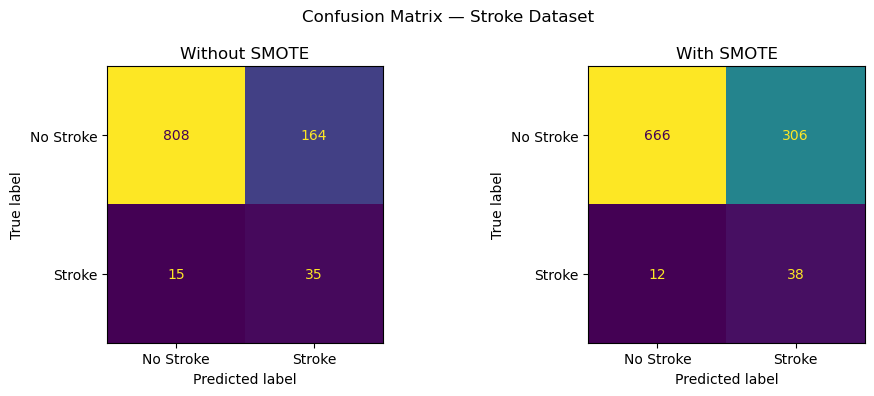

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm1 = confusion_matrix(y_test_stk, (y_prob_no_smote >= 0.3).astype(int))
ConfusionMatrixDisplay(cm1, display_labels=["No Stroke", "Stroke"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Without SMOTE")

cm2 = confusion_matrix(y_test_stk, (y_prob_smote >= 0.3).astype(int))
ConfusionMatrixDisplay(cm2, display_labels=["No Stroke", "Stroke"]).plot(ax=axes[1], colorbar=False)
axes[1].set_title("With SMOTE")

plt.suptitle("Confusion Matrix — Stroke Dataset")
plt.tight_layout()
plt.savefig("confusion_matrix_stroke1.png", dpi=150, bbox_inches="tight")
plt.show()

In [34]:
torch.manual_seed(42)
model_ht, y_prob_ht = train_baseline_nn(X_train_ht_scaled, y_train_ht, X_test_ht_scaled, y_test_ht, threshold=0.5)

Epoch 10/50 | Loss: 0.0210
Epoch 20/50 | Loss: 0.0212
Epoch 30/50 | Loss: 0.0187
Epoch 40/50 | Loss: 0.0175
Epoch 50/50 | Loss: 0.0181

  Classifier NN Results     
AUC-ROC : 0.9333
AUC-PR  : 0.9257
Recall  : 0.9118
F1 Score: 0.8986
              precision    recall  f1-score   support

          No       0.89      0.85      0.87        82
         Yes       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



# Benchmark Models

In [35]:
def train_benchmarks(X_train, y_train, X_test, y_test, scale_pos_weight=19, threshold=0.3):
    
    benchmarks = {
        "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000),
        "Random Forest":       RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42),
        "XGBoost":             XGBClassifier(scale_pos_weight=scale_pos_weight,
                                             eval_metric="aucpr", random_state=42)
    }
    results = {}
    for name, clf in benchmarks.items():
        clf.fit(X_train, y_train)
        y_prob = clf.predict_proba(X_test)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)
        print(f"\n── {name}")
        metrics = evaluate_model(y_test, y_pred, y_prob, model_name=name)
        results[name] = {"model": clf, "proba": y_prob, "metrics": metrics}
    
    return results

In [36]:
benchmark_results_stk = train_benchmarks(X_train_stk_bal, y_train_stk_bal, X_test_stk_scaled, y_test_stk)


── Logistic Regression
AUC-ROC : 0.8407
AUC-PR  : 0.2901
Recall  : 0.8400
F1 Score: 0.1768
              precision    recall  f1-score   support

          No       0.99      0.61      0.75       972
         Yes       0.10      0.84      0.18        50

    accuracy                           0.62      1022
   macro avg       0.54      0.72      0.46      1022
weighted avg       0.94      0.62      0.72      1022


── Random Forest
AUC-ROC : 0.7608
AUC-PR  : 0.1303
Recall  : 0.3800
F1 Score: 0.1836
              precision    recall  f1-score   support

          No       0.96      0.86      0.91       972
         Yes       0.12      0.38      0.18        50

    accuracy                           0.83      1022
   macro avg       0.54      0.62      0.55      1022
weighted avg       0.92      0.83      0.87      1022


── XGBoost
AUC-ROC : 0.7381
AUC-PR  : 0.1179
Recall  : 0.4000
F1 Score: 0.1717
              precision    recall  f1-score   support

          No       0.96      0.83

In [37]:
benchmark_results_stk_no_smote = train_benchmarks(X_train_stk_scaled, y_train_stk, X_test_stk_scaled, y_test_stk)


── Logistic Regression
AUC-ROC : 0.8396
AUC-PR  : 0.2584
Recall  : 0.8400
F1 Score: 0.1707
              precision    recall  f1-score   support

          No       0.99      0.59      0.74       972
         Yes       0.10      0.84      0.17        50

    accuracy                           0.60      1022
   macro avg       0.54      0.71      0.45      1022
weighted avg       0.94      0.60      0.71      1022


── Random Forest
AUC-ROC : 0.7880
AUC-PR  : 0.1444
Recall  : 0.0800
F1 Score: 0.1096
              precision    recall  f1-score   support

          No       0.95      0.98      0.97       972
         Yes       0.17      0.08      0.11        50

    accuracy                           0.94      1022
   macro avg       0.56      0.53      0.54      1022
weighted avg       0.92      0.94      0.93      1022


── XGBoost
AUC-ROC : 0.7699
AUC-PR  : 0.1611
Recall  : 0.2800
F1 Score: 0.2171
              precision    recall  f1-score   support

          No       0.96      0.93

In [38]:
benchmark_results_ht = train_benchmarks(X_train_ht_scaled, y_train_ht, X_test_ht_scaled, y_test_ht, scale_pos_weight=1, threshold=0.5)


── Logistic Regression
AUC-ROC : 0.9293
AUC-PR  : 0.9364
Recall  : 0.9314
F1 Score: 0.9048
              precision    recall  f1-score   support

          No       0.91      0.84      0.87        82
         Yes       0.88      0.93      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184


── Random Forest
AUC-ROC : 0.9308
AUC-PR  : 0.9302
Recall  : 0.9314
F1 Score: 0.9091
              precision    recall  f1-score   support

          No       0.91      0.85      0.88        82
         Yes       0.89      0.93      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.89      0.89       184
weighted avg       0.90      0.90      0.90       184


── XGBoost
AUC-ROC : 0.9219
AUC-PR  : 0.9284
Recall  : 0.8725
F1 Score: 0.8725
              precision    recall  f1-score   support

          No       0.84      0.84

In [39]:
lr_model = benchmark_results_stk_no_smote["Logistic Regression"]["model"]
y_prob_lr_no_smote = benchmark_results_stk_no_smote["Logistic Regression"]["proba"]

## FAIRNESS CHECK

In [40]:
from fairlearn.metrics import MetricFrame, demographic_parity_difference, equalized_odds_difference, equal_opportunity_difference

In [41]:
def fairness_audit(y_true, y_pred, y_prob, protected_df, stage_name="Classifier", attrs=["gender", "age_group"]):
   
    # Measure group fairness metrics across gender AND age groups.
    
    print(f"\n{'='*60}")
    print(f" FAIRNESS AUDIT — {stage_name}")
    print(f"{'='*60}")
    results = {}
 
    for attr in attrs:
        groups = protected_df[attr]
        print(f"\n── Protected Attribute: {attr}          ")
 
        dpd = demographic_parity_difference(y_true, y_pred, sensitive_features=groups)
 
        # difference in TPR AND FPR across groups — clinical gold standard
        eqo = equalized_odds_difference(y_true, y_pred, sensitive_features=groups)

        # difference in recall/TPR across groups
        eod = equal_opportunity_difference(y_true, y_pred, sensitive_features=groups)
 
        print(f"Demographic Parity Difference  : {dpd:.4f}")
        print(f"Equal Opportunity Difference   : {eod:.4f}")
        print(f"Equalized Odds Difference      : {eqo:.4f}")
        
        
        # MetricFrame — per-group breakdown
        mf = MetricFrame(
            metrics={
                "recall":    recall_score,
                "f1":        f1_score,
                "auc_roc":   roc_auc_score
            },
            y_true=y_true,
            y_pred=y_pred,
            sensitive_features=groups
        )
        print(f"\nPer-group metrics:\n{mf.by_group}")
        results[attr] = {"dpd": dpd, "eod": eod, "eqo": eqo} 

    return results 
 
        # Visualize per-group recall
        # mf.by_group["recall"].plot(kind="bar", title=f"Recall by {attr} — {stage_name}", edgecolor="black")
        # plt.ylabel("Recall")
        # plt.tight_layout()
        # plt.savefig(f"fairness_recall_{attr}_{stage_name.replace(' ', '_')}.png", dpi=150)
        # plt.show()

In [42]:
y_pred_no_smote = (y_prob_no_smote >= 0.3).astype(int)
fairness_audit(y_test_stk, y_pred_no_smote, y_prob_no_smote, prot_test_stk, stage_name="Stroke No SMOTE")


 FAIRNESS AUDIT — Stroke No SMOTE

── Protected Attribute: gender          
Demographic Parity Difference  : 0.0030
Equal Opportunity Difference   : 0.1396
Equalized Odds Difference      : 0.1396

Per-group metrics:
          recall        f1   auc_roc
gender                              
0       0.758621  0.301370  0.795684
1       0.619048  0.252427  0.724128

── Protected Attribute: age_group          
Demographic Parity Difference  : 0.6899
Equal Opportunity Difference   : 0.8947
Equalized Odds Difference      : 0.8947

Per-group metrics:
             recall        f1   auc_roc
age_group                              
40-60      0.142857  0.071429  0.539066
<40        0.000000  0.000000  0.500000
>60        0.894737  0.314815  0.620096


{'gender': {'dpd': np.float64(0.0030387230268991983),
  'eod': np.float64(0.1395730706075533),
  'eqo': 0.1395730706075533},
 'age_group': {'dpd': np.float64(0.689922480620155),
  'eod': np.float64(0.8947368421052632),
  'eqo': 0.8947368421052632}}

In [43]:
y_pred_smote = (y_prob_smote >= 0.3).astype(int)
fairness_audit(y_test_stk, y_pred_smote, y_prob_smote, prot_test_stk, stage_name="Stroke SMOTE")


 FAIRNESS AUDIT — Stroke SMOTE

── Protected Attribute: gender          
Demographic Parity Difference  : 0.0929
Equal Opportunity Difference   : 0.1609
Equalized Odds Difference      : 0.1609

Per-group metrics:
          recall        f1   auc_roc
gender                              
0       0.827586  0.189723  0.737737
1       0.666667  0.198582  0.702145

── Protected Attribute: age_group          
Demographic Parity Difference  : 0.8565
Equal Opportunity Difference   : 0.7211
Equalized Odds Difference      : 0.8501

Per-group metrics:
             recall        f1   auc_roc
age_group                              
40-60      0.285714  0.033613  0.464864
<40        0.200000  0.166667  0.593228
>60        0.921053  0.266160  0.528708


{'gender': {'dpd': np.float64(0.09285643905803526),
  'eod': np.float64(0.16091954022988508),
  'eqo': 0.16091954022988508},
 'age_group': {'dpd': np.float64(0.856468023255814),
  'eod': np.float64(0.7210526315789474),
  'eqo': 0.8500923455776729}}

In [44]:
y_pred_ht = (y_prob_ht >= 0.5).astype(int)
fairness_audit(y_test_ht, y_pred_ht, y_prob_ht, prot_test_ht, stage_name="Heart", attrs=["Sex", "age_group"])


 FAIRNESS AUDIT — Heart

── Protected Attribute: Sex          
Demographic Parity Difference  : 0.5202
Equal Opportunity Difference   : 0.0833
Equalized Odds Difference      : 0.1888

Per-group metrics:
       recall        f1   auc_roc
Sex                              
0    0.833333  0.833333  0.901042
1    0.916667  0.902564  0.848333

── Protected Attribute: age_group          
Demographic Parity Difference  : 0.7432
Equal Opportunity Difference   : 0.1111
Equalized Odds Difference      : 0.2000

Per-group metrics:
             recall        f1   auc_roc
age_group                              
40-60      0.888889  0.870748  0.852778
<40        1.000000  1.000000  1.000000
>60        0.964286  0.964286  0.882143


{'Sex': {'dpd': np.float64(0.5201874549387167),
  'eod': np.float64(0.08333333333333326),
  'eqo': 0.18875},
 'age_group': {'dpd': np.float64(0.7432216905901117),
  'eod': np.float64(0.11111111111111116),
  'eqo': 0.2}}

## Bias Mitigation

### Three mitigation strategies: Pre / In / Post processing

#### Reweighing (AIF360)

In [45]:
!pip install aif360

In [46]:
from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.preprocessing import Reweighing

pip install 'aif360[inFairness]'


In [47]:
def apply_reweighing(X_train, y_train, prot_train, X_test, epochs=50, lr=0.001, protected_attr="age_group"):

    train_df = pd.DataFrame(X_train)
    train_df["target"] = y_train.values if hasattr(y_train, "values") else y_train
    age_map = {"<40": 0, "40-60": 1, ">60": 2}
    train_df["age_group"] = prot_train["age_group"].map(age_map).values

    aif_dataset = BinaryLabelDataset(
        df=train_df,
        label_names=["target"],
        protected_attribute_names=["age_group"]
    )

    privileged   = [{"age_group": 2}]
    unprivileged = [{"age_group": 0}, {"age_group": 1}]

    rw = Reweighing(unprivileged_groups=unprivileged, privileged_groups=privileged)
    rw.fit(aif_dataset)
    transformed    = rw.transform(aif_dataset)
    sample_weights = transformed.instance_weights

    print(f"Reweighing applied — weight range: {sample_weights.min():.3f} to {sample_weights.max():.3f}")

    w_tr      = torch.FloatTensor(sample_weights)
    input_dim = X_train.shape[1]
    model     = ClassifierNN(input_dim)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    X_tr = torch.FloatTensor(X_train)
    y_tr = torch.FloatTensor(y_train.values if hasattr(y_train, "values") else y_train).unsqueeze(1)
    X_te = torch.FloatTensor(X_test)

    dataset    = TensorDataset(X_tr, y_tr, w_tr)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for X_batch, y_batch, w_batch in dataloader:
            optimizer.zero_grad()
            preds = model(X_batch)

            # Per-sample focal loss (reduction="none" manually applied here)
            bce_per_sample   = nn.functional.binary_cross_entropy(preds, y_batch, reduction="none")
            pt                = torch.exp(-bce_per_sample)
            focal_per_sample  = 0.25 * (1 - pt) ** 2.0 * bce_per_sample   # alpha=0.25, gamma=2.0

            # Ab per-sample weight sahi se apply hoga
            loss = (focal_per_sample.squeeze() * w_batch).mean()

            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss/len(dataloader):.4f}")

    model.eval()
    with torch.no_grad():
        y_prob = model(X_te).squeeze().numpy()

    return model, y_prob       

In [48]:
model_rw_stk, y_prob_rw_stk = apply_reweighing(X_train_stk_scaled, y_train_stk, prot_train_stk, X_test_stk_scaled)

Reweighing applied — weight range: 0.366 to 2.468
Epoch 10/50 | Loss: 0.0121
Epoch 20/50 | Loss: 0.0110
Epoch 30/50 | Loss: 0.0108
Epoch 40/50 | Loss: 0.0105
Epoch 50/50 | Loss: 0.0099


In [49]:
fairness_audit(y_test_stk, (y_prob_rw_stk >= 0.3).astype(int), y_prob_rw_stk, prot_test_stk, stage_name="Reweighing Stroke")


 FAIRNESS AUDIT — Reweighing Stroke

── Protected Attribute: gender          
Demographic Parity Difference  : 0.0202
Equal Opportunity Difference   : 0.0624
Equalized Odds Difference      : 0.0624

Per-group metrics:
          recall        f1   auc_roc
gender                              
0       0.413793  0.161074  0.611826
1       0.476190  0.173913  0.634135

── Protected Attribute: age_group          
Demographic Parity Difference  : 0.4939
Equal Opportunity Difference   : 0.5526
Equalized Odds Difference      : 0.5526

Per-group metrics:
             recall        f1   auc_roc
age_group                              
40-60      0.142857  0.021739  0.435506
<40        0.000000  0.000000  0.498871
>60        0.552632  0.253012  0.533134


{'gender': {'dpd': np.float64(0.020171445462607157),
  'eod': np.float64(0.06239737274220031),
  'eqo': 0.06239737274220031},
 'age_group': {'dpd': np.float64(0.4938918881506091),
  'eod': np.float64(0.5526315789473685),
  'eqo': 0.5526315789473685}}

In [50]:
model_rw_ht, y_prob_rw_ht = apply_reweighing(X_train_ht_scaled, y_train_ht, prot_train_ht, X_test_ht_scaled)

Reweighing applied — weight range: 0.782 to 1.527
Epoch 10/50 | Loss: 0.0224
Epoch 20/50 | Loss: 0.0205
Epoch 30/50 | Loss: 0.0212
Epoch 40/50 | Loss: 0.0188
Epoch 50/50 | Loss: 0.0184


In [51]:
fairness_audit(y_test_ht, (y_prob_rw_ht >= 0.5).astype(int), y_prob_rw_ht, prot_test_ht, stage_name="Reweighing Heart", attrs=["Sex", "age_group"])


 FAIRNESS AUDIT — Reweighing Heart

── Protected Attribute: Sex          
Demographic Parity Difference  : 0.5281
Equal Opportunity Difference   : 0.1146
Equalized Odds Difference      : 0.1975

Per-group metrics:
       recall        f1   auc_roc
Sex                              
0    0.833333  0.769231  0.885417
1    0.947917  0.910000  0.843958

── Protected Attribute: age_group          
Demographic Parity Difference  : 0.7735
Equal Opportunity Difference   : 0.0833
Equalized Odds Difference      : 0.2333

Per-group metrics:
             recall        f1   auc_roc
age_group                              
40-60      0.916667  0.868421  0.841667
<40        1.000000  1.000000  1.000000
>60        1.000000  0.982456  0.900000


{'Sex': {'dpd': np.float64(0.5281182408074981),
  'eod': np.float64(0.11458333333333326),
  'eqo': 0.1975},
 'age_group': {'dpd': np.float64(0.773524720893142),
  'eod': np.float64(0.08333333333333337),
  'eqo': 0.23333333333333334}}

#### Adversarial Debiasing Neural Network

In [52]:
class AdversarialDebiasingNN(nn.Module):
    
    def __init__(self, input_dim, n_protected=3):
        super(AdversarialDebiasingNN, self).__init__()

        self.predictor_shared = nn.Sequential(nn.Linear(input_dim, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64, 32), nn.ReLU())
        self.predictor_head = nn.Sequential(nn.Linear(32, 16), nn.ReLU(), nn.Linear(16, 1), nn.Sigmoid())

        self.adversary = nn.Sequential(nn.Linear(32, 16), nn.ReLU(), nn.Linear(16, n_protected), nn.Softmax(dim=1))

    def forward(self, x):
        shared   = self.predictor_shared(x)
        pred_out = self.predictor_head(shared)
        adv_out  = self.adversary(shared)
        return pred_out, adv_out, shared


def train_adversarial_nn(X_train, y_train, protected_train, X_test, y_test, protected_test, lambda_adv=1.0, epochs=50, lr=0.001):
    input_dim = X_train.shape[1]
    model    = AdversarialDebiasingNN(input_dim, n_protected=3)          

    pred_optimizer = optim.Adam(list(model.predictor_shared.parameters()) + list(model.predictor_head.parameters()), lr=lr)
    adv_optimizer  = optim.Adam(model.adversary.parameters(), lr=lr)

    pred_criterion = FocalLoss(alpha=0.25, gamma=2.0)
    adv_criterion  = nn.CrossEntropyLoss()                                

    X_tr = torch.FloatTensor(X_train)
    y_tr = torch.FloatTensor(y_train.values if hasattr(y_train, "values") else y_train).unsqueeze(1)

    age_map = {"<40": 0, "40-60": 1, ">60": 2}                           
    prot_tr = torch.LongTensor(protected_train["age_group"].map(age_map).values)                                                                      

    dataset    = TensorDataset(X_tr, y_tr, prot_tr)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

    model.train()
    for epoch in range(epochs):
        for X_batch, y_batch, prot_batch in dataloader:

            # Step 1: Update Adversary
            adv_optimizer.zero_grad()
            _, adv_out, _ = model(X_batch)
            adv_loss = adv_criterion(adv_out, prot_batch.long())          
            adv_loss.backward()
            adv_optimizer.step()

            # Step 2: Update Predictor
            pred_optimizer.zero_grad()
            pred_out, adv_out, _ = model(X_batch)
            pred_loss  = pred_criterion(pred_out, y_batch)
            adv_loss2  = adv_criterion(adv_out, prot_batch.long())        
            total_loss = pred_loss - lambda_adv * adv_loss2
            total_loss.backward()
            pred_optimizer.step()

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Pred Loss: {pred_loss.item():.4f} | Adv Loss: {adv_loss2.item():.4f}")

    return model

In [53]:
torch.manual_seed(42)
fair_model_stk = train_adversarial_nn(X_train_stk_scaled, y_train_stk, prot_train_stk, X_test_stk_scaled, y_test_stk, prot_test_stk, lambda_adv=1.0, epochs=50)

Epoch 10/50 | Pred Loss: 0.0187 | Adv Loss: 1.1596
Epoch 20/50 | Pred Loss: 0.0079 | Adv Loss: 1.1350
Epoch 30/50 | Pred Loss: 0.0035 | Adv Loss: 1.0446
Epoch 40/50 | Pred Loss: 0.0117 | Adv Loss: 1.2243
Epoch 50/50 | Pred Loss: 0.0158 | Adv Loss: 1.1515


In [54]:
fair_model_stk.eval()
with torch.no_grad():
    fair_probs_stk, _, _ = fair_model_stk(torch.FloatTensor(X_test_stk_scaled))
    fair_probs_stk = fair_probs_stk.squeeze().numpy()
fair_preds_stk = (fair_probs_stk >= 0.3).astype(int)
fairness_audit(y_test_stk, fair_preds_stk, fair_probs_stk, prot_test_stk, stage_name="Adversarial NN Stroke")


 FAIRNESS AUDIT — Adversarial NN Stroke

── Protected Attribute: gender          
Demographic Parity Difference  : 0.0056
Equal Opportunity Difference   : 0.0624
Equalized Odds Difference      : 0.0624

Per-group metrics:
          recall        f1   auc_roc
gender                              
0       0.586207  0.306306  0.735885
1       0.523810  0.285714  0.706212

── Protected Attribute: age_group          
Demographic Parity Difference  : 0.4806
Equal Opportunity Difference   : 0.7105
Equalized Odds Difference      : 0.7105

Per-group metrics:
             recall        f1   auc_roc
age_group                              
40-60      0.142857  0.095238  0.550393
<40        0.000000  0.000000  0.500000
>60        0.710526  0.333333  0.634809


{'gender': {'dpd': np.float64(0.005588727953492939),
  'eod': np.float64(0.06239737274220025),
  'eqo': 0.06239737274220025},
 'age_group': {'dpd': np.float64(0.4806201550387597),
  'eod': np.float64(0.7105263157894737),
  'eqo': 0.7105263157894737}}

In [55]:
torch.manual_seed(42)
fair_model_ht = train_adversarial_nn(X_train_ht_scaled, y_train_ht, prot_train_ht, X_test_ht_scaled, y_test_ht, prot_test_ht, lambda_adv=1.0, epochs=50)

Epoch 10/50 | Pred Loss: 0.0237 | Adv Loss: 0.9936
Epoch 20/50 | Pred Loss: 0.0437 | Adv Loss: 1.0080
Epoch 30/50 | Pred Loss: 0.0223 | Adv Loss: 1.0382
Epoch 40/50 | Pred Loss: 0.0163 | Adv Loss: 0.9306
Epoch 50/50 | Pred Loss: 0.0119 | Adv Loss: 0.9486


In [56]:
fair_model_ht.eval()
with torch.no_grad():
    fair_probs_ht, _, _ = fair_model_ht(torch.FloatTensor(X_test_ht_scaled))
    fair_probs_ht = fair_probs_ht.squeeze().numpy()
fair_preds_ht = (fair_probs_ht >= 0.5).astype(int)
fairness_audit(y_test_ht, fair_preds_ht, fair_probs_ht, prot_test_ht, stage_name="Adversarial NN Heart", attrs=["Sex", "age_group"])


 FAIRNESS AUDIT — Adversarial NN Heart

── Protected Attribute: Sex          
Demographic Parity Difference  : 0.5270
Equal Opportunity Difference   : 0.0938
Equalized Odds Difference      : 0.1888

Per-group metrics:
       recall        f1   auc_roc
Sex                              
0    0.833333  0.833333  0.901042
1    0.927083  0.908163  0.853542

── Protected Attribute: age_group          
Demographic Parity Difference  : 0.7735
Equal Opportunity Difference   : 0.0972
Equalized Odds Difference      : 0.4000

Per-group metrics:
             recall        f1   auc_roc
age_group                              
40-60      0.902778  0.884354  0.868056
<40        1.000000  1.000000  1.000000
>60        0.964286  0.947368  0.782143


{'Sex': {'dpd': np.float64(0.5270367700072098),
  'eod': np.float64(0.09375),
  'eqo': 0.18875},
 'age_group': {'dpd': np.float64(0.773524720893142),
  'eod': np.float64(0.09722222222222221),
  'eqo': 0.4}}

#### Equal Opportunity Thresholding (Fairlearn)

In [57]:
from fairlearn.postprocessing import ThresholdOptimizer

In [58]:
def apply_threshold_optimizer(base_clf, X_train, y_train, prot_train,
                               X_test, y_test, prot_test):

    np.random.seed(42)
    optimizer = ThresholdOptimizer(
        estimator=base_clf,
        constraints="true_positive_rate_parity",
        objective="balanced_accuracy_score",
        predict_method="predict_proba",
    )
    optimizer.fit(X_train, y_train, sensitive_features=prot_train["age_group"])
 
    y_pred_fair = optimizer.predict(X_test, sensitive_features=prot_test["age_group"])
 
    print("\n── Post-Processing Results (ThresholdOptimizer) ──")
    evaluate_model(y_test, y_pred_fair,
                   y_pred_fair.astype(float),   
                   model_name="Post-Process Fair")
 
    return optimizer, y_pred_fair

In [59]:
base_clf_stk = lr_model
optimizer_stk, y_pred_fair_stk = apply_threshold_optimizer(base_clf_stk, X_train_stk_scaled, y_train_stk, prot_train_stk, X_test_stk_scaled, y_test_stk, prot_test_stk)


── Post-Processing Results (ThresholdOptimizer) ──
AUC-ROC : 0.7227
AUC-PR  : 0.1039
Recall  : 0.6800
F1 Score: 0.2179
              precision    recall  f1-score   support

          No       0.98      0.77      0.86       972
         Yes       0.13      0.68      0.22        50

    accuracy                           0.76      1022
   macro avg       0.55      0.72      0.54      1022
weighted avg       0.94      0.76      0.83      1022



In [60]:
fairness_audit(y_test_stk, y_pred_fair_stk, y_pred_fair_stk.astype(float), prot_test_stk, stage_name="ThresholdOptimizer Stroke")


 FAIRNESS AUDIT — ThresholdOptimizer Stroke

── Protected Attribute: gender          
Demographic Parity Difference  : 0.0401
Equal Opportunity Difference   : 0.1872
Equalized Odds Difference      : 0.1872

Per-group metrics:
          recall        f1   auc_roc
gender                              
0       0.758621  0.229167  0.755191
1       0.571429  0.200000  0.678041

── Protected Attribute: age_group          
Demographic Parity Difference  : 0.3775
Equal Opportunity Difference   : 0.3368
Equalized Odds Difference      : 0.3368

Per-group metrics:
             recall        f1   auc_roc
age_group                              
40-60      0.571429  0.074766  0.630374
<40        0.400000  0.086957  0.655982
>60        0.736842  0.352201  0.657057


{'gender': {'dpd': np.float64(0.040090649325056654),
  'eod': np.float64(0.18719211822660098),
  'eqo': 0.18719211822660098},
 'age_group': {'dpd': np.float64(0.37747439091915835),
  'eod': np.float64(0.33684210526315783),
  'eqo': 0.33684210526315783}}

In [61]:
base_clf_ht = benchmark_results_ht["Logistic Regression"]["model"]
optimizer_ht, y_pred_fair_ht = apply_threshold_optimizer(base_clf_ht, X_train_ht_scaled, y_train_ht, prot_train_ht, X_test_ht_scaled, y_test_ht, prot_test_ht)


── Post-Processing Results (ThresholdOptimizer) ──
AUC-ROC : 0.8473
AUC-PR  : 0.8156
Recall  : 0.9020
F1 Score: 0.8720
              precision    recall  f1-score   support

          No       0.87      0.79      0.83        82
         Yes       0.84      0.90      0.87       102

    accuracy                           0.85       184
   macro avg       0.86      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



In [62]:
fairness_audit(y_test_ht, y_pred_fair_ht, y_pred_fair_ht.astype(float), prot_test_ht, stage_name="ThresholdOptimizer Heart", attrs=["Sex", "age_group"])


 FAIRNESS AUDIT — ThresholdOptimizer Heart

── Protected Attribute: Sex          
Demographic Parity Difference  : 0.4813
Equal Opportunity Difference   : 0.0729
Equalized Odds Difference      : 0.1863

Per-group metrics:
       recall        f1   auc_roc
Sex                              
0    0.833333  0.714286  0.869792
1    0.906250  0.883249  0.813125

── Protected Attribute: age_group          
Demographic Parity Difference  : 0.6826
Equal Opportunity Difference   : 0.1071
Equalized Odds Difference      : 0.2667

Per-group metrics:
             recall        f1   auc_roc
age_group                              
40-60      0.902778  0.849673  0.818056
<40        1.000000  1.000000  1.000000
>60        0.892857  0.925926  0.846429


{'Sex': {'dpd': np.float64(0.48125450612833454),
  'eod': np.float64(0.07291666666666663),
  'eqo': 0.18625000000000003},
 'age_group': {'dpd': np.float64(0.682615629984051),
  'eod': np.float64(0.1071428571428571),
  'eqo': 0.26666666666666666}}

In [63]:
# STROKE
res_baseline_stk_smote = fairness_audit(y_test_stk, y_pred_smote, y_prob_smote, prot_test_stk, stage_name="Stroke SMOTE")
res_baseline_stk = fairness_audit(y_test_stk, y_pred_no_smote, y_prob_no_smote, prot_test_stk, stage_name="Stroke No SMOTE")
res_rw_stk = fairness_audit(y_test_stk, (y_prob_rw_stk >= 0.3).astype(int), y_prob_rw_stk, prot_test_stk, stage_name="Reweighing Stroke")
res_adv_stk = fairness_audit(y_test_stk, fair_preds_stk, fair_probs_stk, prot_test_stk, stage_name="Adversarial NN Stroke")
res_thresh_stk = fairness_audit(y_test_stk, y_pred_fair_stk, y_pred_fair_stk.astype(float), prot_test_stk, stage_name="ThresholdOptimizer Stroke")

# HEART
res_baseline_ht = fairness_audit(y_test_ht, y_pred_ht, y_prob_ht, prot_test_ht, stage_name="Heart Baseline", attrs=["Sex", "age_group"])
res_rw_ht = fairness_audit(y_test_ht, (y_prob_rw_ht >= 0.5).astype(int), y_prob_rw_ht, prot_test_ht, stage_name="Reweighing Heart", attrs=["Sex", "age_group"])
res_adv_ht = fairness_audit(y_test_ht, fair_preds_ht, fair_probs_ht, prot_test_ht, stage_name="Adversarial NN Heart", attrs=["Sex", "age_group"])
res_thresh_ht = fairness_audit(y_test_ht, y_pred_fair_ht, y_pred_fair_ht.astype(float), prot_test_ht, stage_name="ThresholdOptimizer Heart", attrs=["Sex", "age_group"])


 FAIRNESS AUDIT — Stroke SMOTE

── Protected Attribute: gender          
Demographic Parity Difference  : 0.0929
Equal Opportunity Difference   : 0.1609
Equalized Odds Difference      : 0.1609

Per-group metrics:
          recall        f1   auc_roc
gender                              
0       0.827586  0.189723  0.737737
1       0.666667  0.198582  0.702145

── Protected Attribute: age_group          
Demographic Parity Difference  : 0.8565
Equal Opportunity Difference   : 0.7211
Equalized Odds Difference      : 0.8501

Per-group metrics:
             recall        f1   auc_roc
age_group                              
40-60      0.285714  0.033613  0.464864
<40        0.200000  0.166667  0.593228
>60        0.921053  0.266160  0.528708

 FAIRNESS AUDIT — Stroke No SMOTE

── Protected Attribute: gender          
Demographic Parity Difference  : 0.0030
Equal Opportunity Difference   : 0.1396
Equalized Odds Difference      : 0.1396

Per-group metrics:
          recall        f1   auc_roc

## Comparative Fairness Analysis

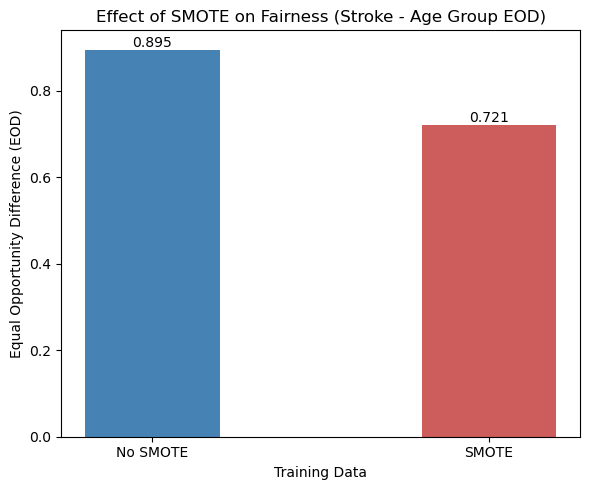

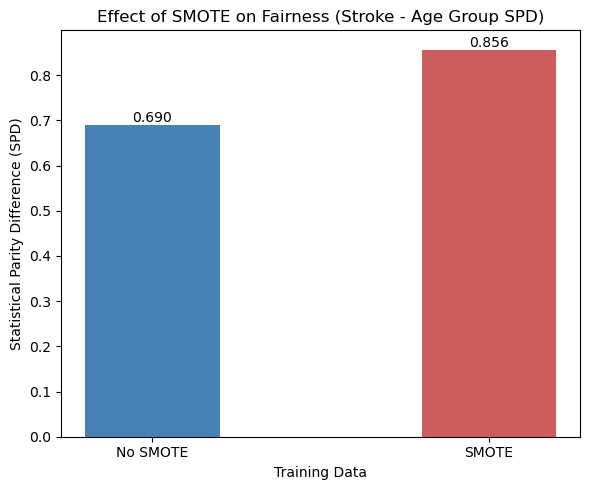

In [64]:
stages = ["No SMOTE", "SMOTE"]
eod_values = [
    res_baseline_stk["age_group"]["eod"],
    res_baseline_stk_smote["age_group"]["eod"]
]

plt.figure(figsize=(6, 5))
bars = plt.bar(stages, eod_values, color=["steelblue", "indianred"], width=0.4)
plt.title("Effect of SMOTE on Fairness (Stroke - Age Group EOD)")
plt.xlabel("Training Data")
plt.ylabel("Equal Opportunity Difference (EOD)")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{height:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig("smote_eod_comparison_stroke.png", dpi=300, bbox_inches="tight")
plt.show()

stages = ["No SMOTE", "SMOTE"]
spd_values = [
    res_baseline_stk["age_group"]["dpd"],
    res_baseline_stk_smote["age_group"]["dpd"]
]

plt.figure(figsize=(6, 5))
bars = plt.bar(stages, spd_values, color=["steelblue", "indianred"], width=0.4)
plt.title("Effect of SMOTE on Fairness (Stroke - Age Group SPD)")
plt.xlabel("Training Data")
plt.ylabel("Statistical Parity Difference (SPD)")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{height:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig("smote_spd_comparison_stroke.png", dpi=300, bbox_inches="tight")
plt.show()

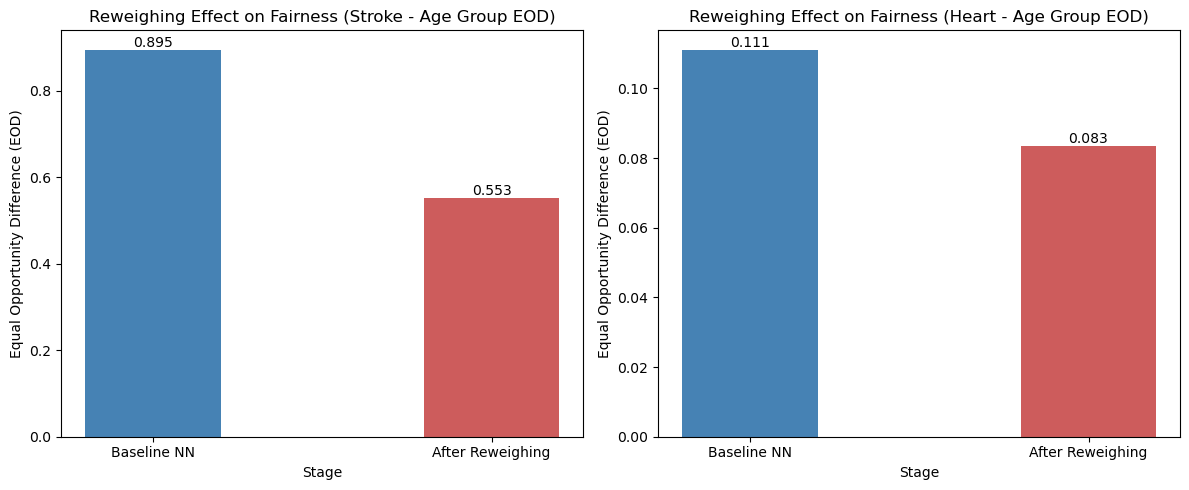

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Stroke
stages = ["Baseline NN", "After Reweighing"]
eod_stk = [res_baseline_stk["age_group"]["eod"], res_rw_stk["age_group"]["eod"]]
bars = axes[0].bar(stages, eod_stk, color=["steelblue", "indianred"], width=0.4)
axes[0].set_title("Reweighing Effect on Fairness (Stroke - Age Group EOD)")
axes[0].set_xlabel("Stage")
axes[0].set_ylabel("Equal Opportunity Difference (EOD)")
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, height, f"{height:.3f}", ha="center", va="bottom")

# Heart
eod_ht = [res_baseline_ht["age_group"]["eod"], res_rw_ht["age_group"]["eod"]]
bars = axes[1].bar(stages, eod_ht, color=["steelblue", "indianred"], width=0.4)
axes[1].set_title("Reweighing Effect on Fairness (Heart - Age Group EOD)")
axes[1].set_xlabel("Stage")
axes[1].set_ylabel("Equal Opportunity Difference (EOD)")
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, height, f"{height:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig("reweighing_eod_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

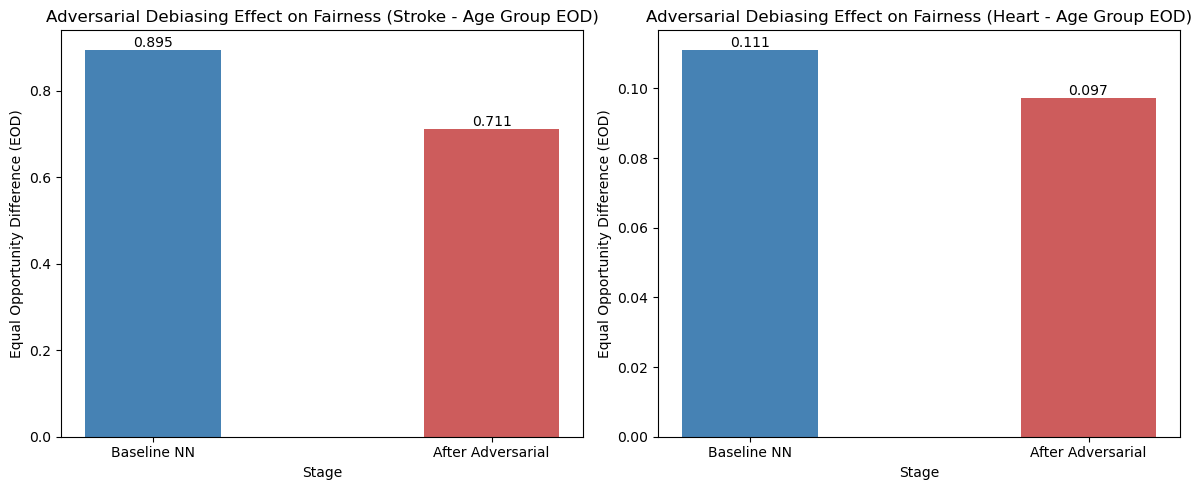

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Stroke
stages = ["Baseline NN", "After Adversarial"]
eod_stk = [res_baseline_stk["age_group"]["eod"], res_adv_stk["age_group"]["eod"]]
bars = axes[0].bar(stages, eod_stk, color=["steelblue", "indianred"], width=0.4)
axes[0].set_title("Adversarial Debiasing Effect on Fairness (Stroke - Age Group EOD)")
axes[0].set_xlabel("Stage")
axes[0].set_ylabel("Equal Opportunity Difference (EOD)")
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, height, f"{height:.3f}", ha="center", va="bottom")

# Heart
eod_ht = [res_baseline_ht["age_group"]["eod"], res_adv_ht["age_group"]["eod"]]
bars = axes[1].bar(stages, eod_ht, color=["steelblue", "indianred"], width=0.4)
axes[1].set_title("Adversarial Debiasing Effect on Fairness (Heart - Age Group EOD)")
axes[1].set_xlabel("Stage")
axes[1].set_ylabel("Equal Opportunity Difference (EOD)")
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, height, f"{height:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig("adversarial_eod_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

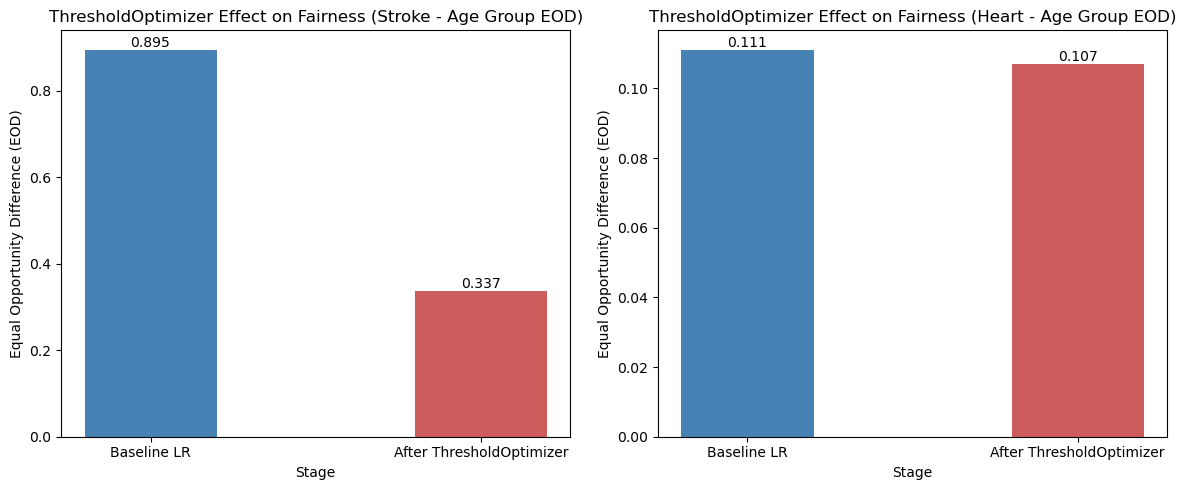

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Stroke
stages = ["Baseline LR", "After ThresholdOptimizer"]
eod_stk = [res_baseline_stk["age_group"]["eod"], res_thresh_stk["age_group"]["eod"]]
bars = axes[0].bar(stages, eod_stk, color=["steelblue", "indianred"], width=0.4)
axes[0].set_title("ThresholdOptimizer Effect on Fairness (Stroke - Age Group EOD)")
axes[0].set_xlabel("Stage")
axes[0].set_ylabel("Equal Opportunity Difference (EOD)")
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, height, f"{height:.3f}", ha="center", va="bottom")

# Heart
eod_ht = [res_baseline_ht["age_group"]["eod"], res_thresh_ht["age_group"]["eod"]]
bars = axes[1].bar(stages, eod_ht, color=["steelblue", "indianred"], width=0.4)
axes[1].set_title("ThresholdOptimizer Effect on Fairness (Heart - Age Group EOD)")
axes[1].set_xlabel("Stage")
axes[1].set_ylabel("Equal Opportunity Difference (EOD)")
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, height, f"{height:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig("threshold_eod_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## SHAP

In [68]:
import shap

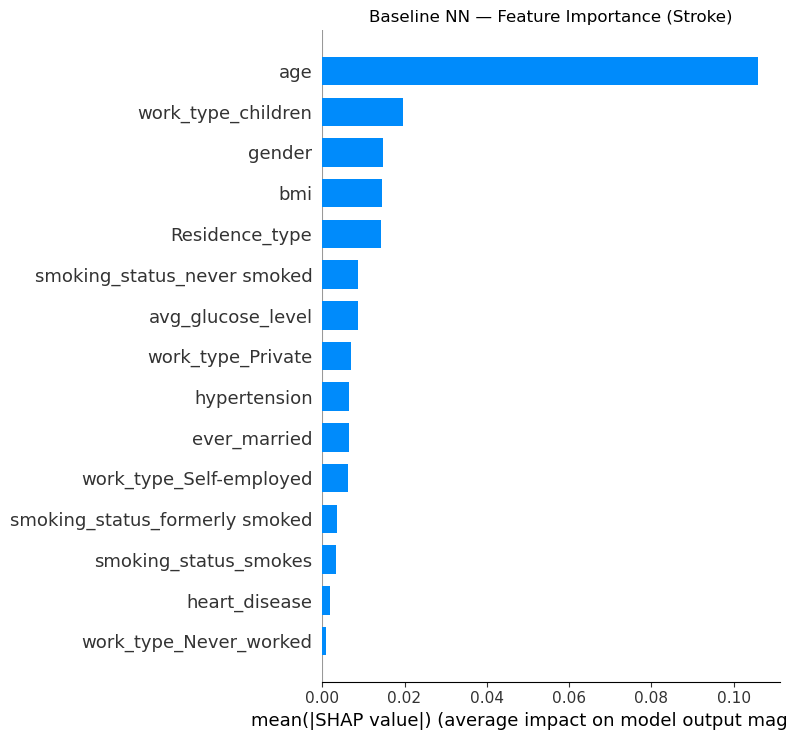

In [75]:
# Baseline NN SHAP — Stroke
background_stk = torch.FloatTensor(X_train_stk_scaled[:100])
explainer_baseline_stk = shap.DeepExplainer(model_no_smote, background_stk)
shap_values_baseline_stk = explainer_baseline_stk.shap_values(torch.FloatTensor(X_test_stk_scaled))
feature_names_stk = X_train_stk.columns.tolist()
shap_vals_stk = np.array(shap_values_baseline_stk)
if shap_vals_stk.ndim == 3:
    shap_vals_stk = shap_vals_stk[:, :, 0]

shap.summary_plot(shap_vals_stk, X_test_stk_scaled, feature_names=feature_names_stk, plot_type="bar", show=False)
plt.title("Baseline NN — Feature Importance (Stroke)")
plt.tight_layout()
plt.savefig("shap_bar_baseline_stroke.png", dpi=150, bbox_inches="tight")
plt.show()

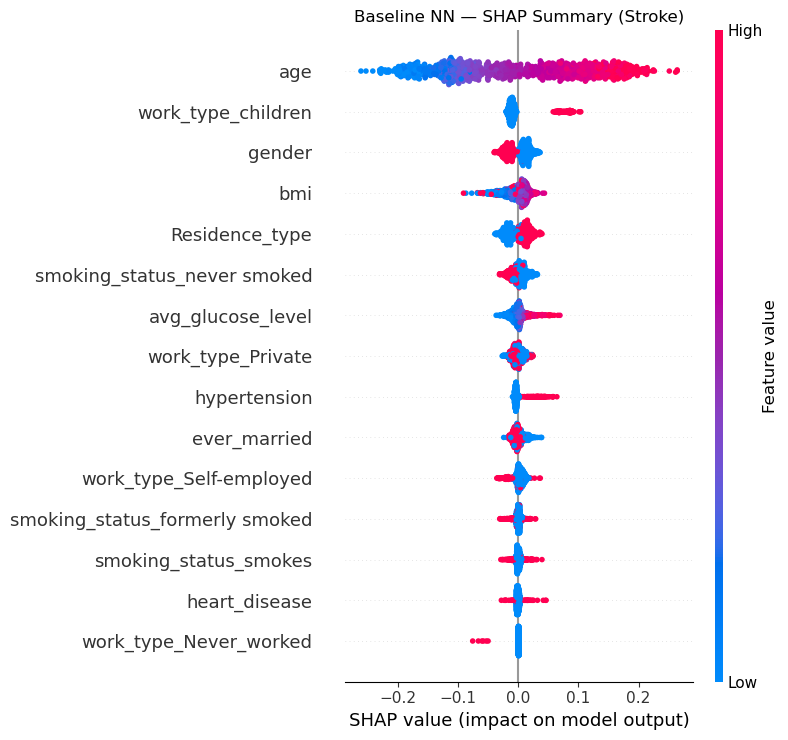

In [76]:
shap.summary_plot(shap_vals_stk, X_test_stk_scaled, feature_names=feature_names_stk, show=False)
plt.title("Baseline NN — SHAP Summary (Stroke)")
plt.tight_layout()
plt.savefig("shap_summary_baseline_stroke.png", dpi=150, bbox_inches="tight")
plt.show()

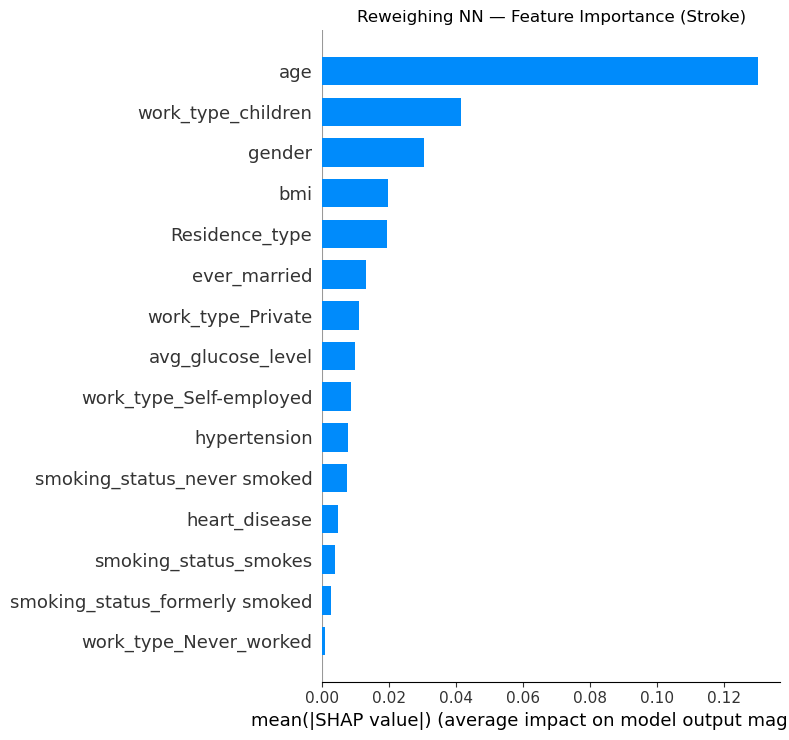

In [71]:
explainer_rw_stk = shap.DeepExplainer(model_rw_stk, background_stk)
shap_values_rw_stk = explainer_rw_stk.shap_values(torch.FloatTensor(X_test_stk_scaled))
shap_vals_rw_stk = np.array(shap_values_rw_stk)
if shap_vals_rw_stk.ndim == 3:
    shap_vals_rw_stk = shap_vals_rw_stk[:, :, 0]
shap.summary_plot(shap_vals_rw_stk, X_test_stk_scaled, feature_names=feature_names_stk, plot_type="bar", show=False)
plt.title("Reweighing NN — Feature Importance (Stroke)")
plt.tight_layout()
plt.savefig("shap_bar_reweighing_stroke.png", dpi=150, bbox_inches="tight")
plt.show()

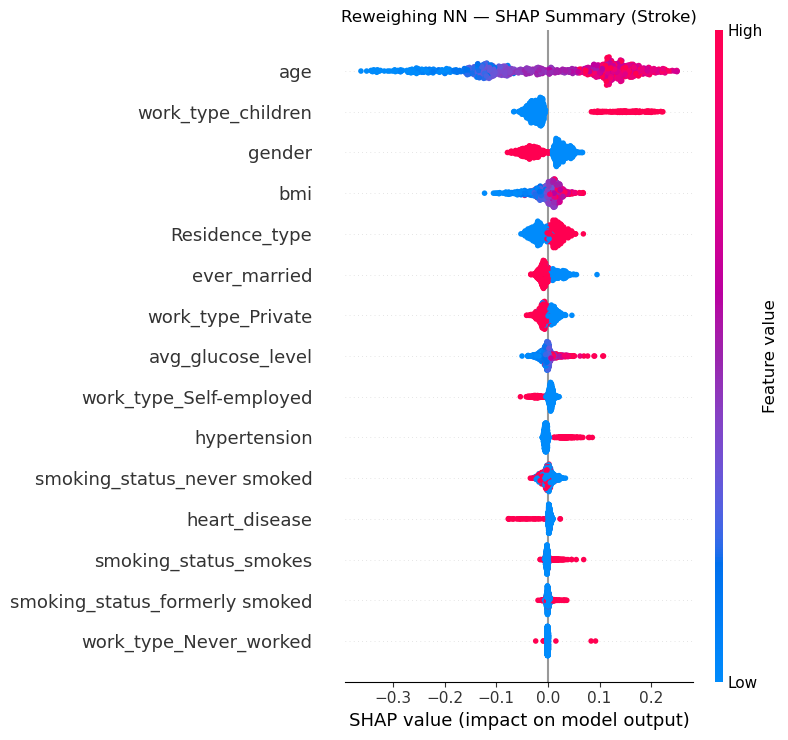

In [72]:
shap.summary_plot(shap_vals_rw_stk, X_test_stk_scaled, feature_names=feature_names_stk, show=False)
plt.title("Reweighing NN — SHAP Summary (Stroke)")
plt.tight_layout()
plt.savefig("shap_summary_reweighing_stroke.png", dpi=150, bbox_inches="tight")
plt.show()

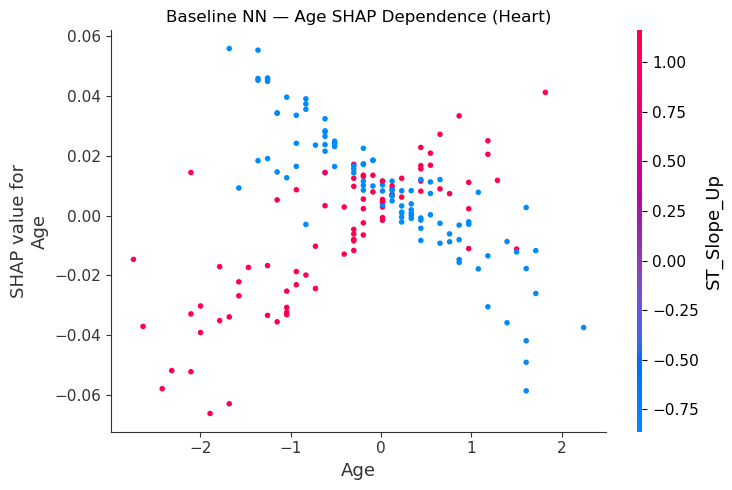

In [73]:
background_ht = torch.FloatTensor(X_train_ht_scaled[:100])
explainer_baseline_ht = shap.DeepExplainer(model_ht, background_ht)
shap_values_baseline_ht = explainer_baseline_ht.shap_values(torch.FloatTensor(X_test_ht_scaled))
feature_names_ht = X_train_ht.columns.tolist()
shap_vals_ht = np.array(shap_values_baseline_ht)
if shap_vals_ht.ndim == 3:
    shap_vals_ht = shap_vals_ht[:, :, 0]

shap.dependence_plot("Age", shap_vals_ht, X_test_ht_scaled, 
                      feature_names=feature_names_ht, show=False)
plt.title("Baseline NN — Age SHAP Dependence (Heart)")
plt.tight_layout()
plt.savefig("shap_dependence_age_baseline_heart.png", dpi=150, bbox_inches="tight")
plt.show()

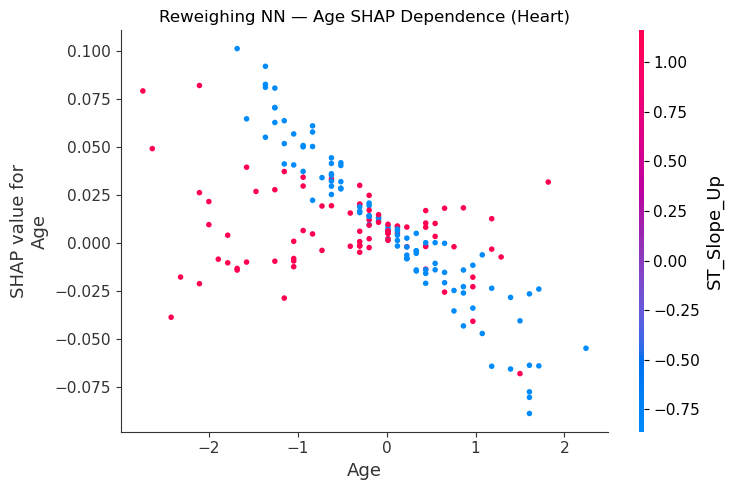

In [74]:
explainer_rw_ht = shap.DeepExplainer(model_rw_ht, background_ht)
shap_values_rw_ht = explainer_rw_ht.shap_values(torch.FloatTensor(X_test_ht_scaled))
shap_vals_rw_ht = np.array(shap_values_rw_ht)
if shap_vals_rw_ht.ndim == 3:
    shap_vals_rw_ht = shap_vals_rw_ht[:, :, 0]

shap.dependence_plot("Age", shap_vals_rw_ht, X_test_ht_scaled, 
                      feature_names=feature_names_ht, show=False)
plt.title("Reweighing NN — Age SHAP Dependence (Heart)")
plt.tight_layout()
plt.savefig("shap_dependence_age_heart.png", dpi=150, bbox_inches="tight")
plt.show()